# Preprocessing Ulasan Ride-Hailing (Gojek, Grab, Maxim)
**Task:** Klasifikasi Subjektif-Objektif  


## 0. Instalasi & Import

In [1]:
import pandas as pd
import re
from collections import Counter
from sklearn.utils import resample

pd.set_option('display.max_colwidth', 120)


---
## 1. Load Data & Seleksi Kolom
Mengambil kolom `review` dan `label`   
- `label = 0` = **Objektif**  
- `label = 1` = **Subjektif**

In [2]:
df = pd.read_csv('../dataset/subride.csv')

#Menampilkan kolom yang tersedia
print("Kolom tersedia:", df.columns.tolist())
print("Shape awal    :", df.shape)
df.head(3)

Kolom tersedia: ['score', 'app', 'review', 'translated_review', 'label']
Shape awal    : (1338, 5)


,score,app,review,translated_review,label
0,5,Maxim,semoga kedepannya talangan g susah dapatnya karna saya jualan pake jasa maxim yg perlu talangan lama banget kalau ca...,"Hopefully in the future it won’t be so hard to find drivers who are willing to front the money, because I use Maxim ...",1
1,3,Grab,tolong buat pusat grab perbaiki lagi jangan dikit di tangguhkan dan buat para driver jngn gampang melaporkan krna la...,"Please Grab HQ, improve your system — don't suspend drivers so easily, and tell drivers not to report over small thi...",1
2,1,Gojek,woi gojek kalo mau bikin verifikasi minimal bisa depan belakang lah kamera ini depan doang apa si dulu ga pake verif...,"Hey Gojek, if you're going to do face verification, at least use front and back cameras. This one’s just front-facin...",1


In [3]:
#Mengambil kolom review + label
df = df[['review', 'label']].copy()
print("Shape setelah seleksi kolom:", df.shape)
df.head(3)


Shape setelah seleksi kolom: (1338, 2)


,review,label
0,semoga kedepannya talangan g susah dapatnya karna saya jualan pake jasa maxim yg perlu talangan lama banget kalau ca...,1
1,tolong buat pusat grab perbaiki lagi jangan dikit di tangguhkan dan buat para driver jngn gampang melaporkan krna la...,1
2,woi gojek kalo mau bikin verifikasi minimal bisa depan belakang lah kamera ini depan doang apa si dulu ga pake verif...,1


---
## 2. Lowercase
Seluruh teks ulasan diubah ke huruf kecil agar konsisten.

In [5]:
df['review'] = df['review'].str.lower().str.strip()

---
## 3. Pengecekan Awal Kolom Review
Melihat nilai null, duplikat, baris kosong, dan distribusi label sebelum preprocessing.

In [6]:
print("Statistik awal")
print(f"Total baris      : {len(df):,}")
print(f"Nilai null       : {df['review'].isnull().sum()}")
print(f"Baris kosong     : {(df['review'].str.strip() == '').sum()}")
print(f"Duplikat review  : {df.duplicated(subset=['review']).sum()}")
print()

print("Distribusi label:")
jumlah_label = df['label'].value_counts()
for label, jumlah in jumlah_label.items():
    nama_label = 'Subjektif' if label == 1 else 'Objektif'
    persen = jumlah / len(df) * 100
    print(f"  Label {label} ({nama_label}): {jumlah:,} ({persen:.1f}%)")

rasio_label = round(jumlah_label[1] / jumlah_label[0], 2)
print(f"  Rasio imbalance: 1 : {rasio_label}")


Statistik awal
Total baris      : 1,338
Nilai null       : 0
Baris kosong     : 0
Duplikat review  : 0

Distribusi label:
  Label 1 (Subjektif): 960 (71.7%)
  Label 0 (Objektif): 378 (28.3%)
  Rasio imbalance: 1 : 2.54


In [7]:
df = df.dropna(subset=['review'])
df = df[df['review'].str.strip() != '']
df = df.drop_duplicates(subset=['review']).reset_index(drop=True)

print(f"Shape setelah pembersihan awal: {df.shape}")


Shape setelah pembersihan awal: (1338, 2)


---
## 4. Normalisasi Teks



### 4A. Kata sambung yang menempel

### 4B. Kata ulang dengan angka 2

### 4C. Angka dan satuan

### 4D. Kamus singkatan dan slang

In [8]:
kamus_normalisasi = {
    #Kata ganti
    'yg'             : 'yang',
    'sy'             : 'saya',
    'gua'            : 'saya',
    'gue'            : 'saya',
    'gw'             : 'saya',
    'ane'            : 'saya',
    'sayaa'          : 'saya',
    'lu'             : 'kamu',
    'lo'             : 'kamu',
    'elu'            : 'kamu',
    'km'             : 'kamu',
    'kmu'            : 'kamu',

    #Kata negasi
    'ga'             : 'tidak',
    'gak'            : 'tidak',
    'gk'             : 'tidak',
    'tdk'            : 'tidak',
    'nggak'          : 'tidak',
    'ngga'           : 'tidak',
    'ngak'           : 'tidak',
    'nggk'           : 'tidak',
    'kaga'           : 'tidak',
    'kagak'          : 'tidak',
    'engga'          : 'tidak',
    'g'              : 'tidak',
    'nga'            : 'tidak',
    'gabisa'         : 'tidak bisa',
    'gamau'          : 'tidak mau',
    'gaada'          : 'tidak ada',
    'gada'           : 'tidak ada',
    'gatau'          : 'tidak tahu',
    'gautau'         : 'tidak tahu',
    'gasuka'         : 'tidak suka',
    'gasih'          : 'tidak sih',
    'gaussah'        : 'tidak usah',
    'gausah'         : 'tidak usah',

    #Kata sambung dan partikel
    'tp'             : 'tapi',
    'tpi'            : 'tapi',
    'jg'             : 'juga',
    'jga'            : 'juga',
    'kl'             : 'kalau',
    'klo'            : 'kalau',
    'klu'            : 'kalau',
    'klw'            : 'kalau',
    'kalo'           : 'kalau',
    'aja'            : 'saja',
    'ajah'           : 'saja',
    'aj'             : 'saja',
    'doang'          : 'saja',
    'sm'             : 'sama',
    'dgn'            : 'dengan',
    'dg'             : 'dengan',
    'pd'             : 'pada',
    'pdhl'           : 'padahal',
    'pdahal'         : 'padahal',
    'pdhal'          : 'padahal',
    'n'              : 'dan',

    #Kata sebab
    'krn'  : 'karena', 'karna': 'karena', 'krna' : 'karena',

    #Kata kondisi
    'klo'  : 'kalau',  'klu'  : 'kalau',  'klw'  : 'kalau',
    'kalo' : 'kalau',

    #Kata penekanan
    'bgt'  : 'banget', 'bngt' : 'banget',
    'sgt'  : 'sangat',

    #Kata kerja dan sifat tidak baku
    'pake'           : 'pakai',
    'pke'            : 'pakai',
    'pakek'          : 'pakai',
    'pesen'          : 'pesan',
    'psen'           : 'pesan',
    'mesen'          : 'pesan',
    'mesan'          : 'pesan',
    'nunggu'         : 'menunggu',
    'nungguin'       : 'menunggu',
    'nyari'          : 'mencari',
    'dapet'          : 'dapat',
    'dpet'           : 'dapat',
    'dpt'            : 'dapat',
    'dpat'           : 'dapat',
    'ngerti'         : 'mengerti',
    'ngasih'         : 'memberikan',
    'ngambil'        : 'mengambil',
    'ngeluh'         : 'mengeluh',
    'ngomel'         : 'marah',
    'ngejar'         : 'mengejar',
    'denger'         : 'mendengar',
    'inget'          : 'ingat',
    'liat'           : 'lihat',
    'nyoba'          : 'mencoba',
    'nanya'          : 'bertanya',
    'dateng'         : 'datang',
    'naek'           : 'naik',
    'bilng'          : 'bilang',
    'masi'           : 'masih',
    'nerima'         : 'menerima',
    'nolak'          : 'menolak',
    'batalin'        : 'membatalkan',
    'adain'          : 'mengadakan',
    'naikin'         : 'menaikkan',
    'matiin'         : 'mematikan',
    'mantab'         : 'mantap',
    'mantab'         : 'mantap',
    'nyaaa'          : 'nya',
    'nyaa'           : 'nya',
    'ny'             : 'nya',
    'bgt'            : 'banget',
    'bngt'           : 'banget',
    'bgttt'          : 'banget',
    'bener'          : 'benar',
    'sampe'          : 'sampai',
    'sampek'         : 'sampai',
    'smpe'           : 'sampai',
    'tau'            : 'tahu',
    'deket'          : 'dekat',
    'cepet'          : 'cepat',
    'emang'          : 'memang',
    'emng'           : 'memang',
    'kayak'          : 'seperti',
    'kyk'            : 'seperti',
    'kaya'           : 'seperti',
    'nih'            : 'ini',
    'inii'           : 'ini',
    'tuh'            : 'itu',
    'gitu'           : 'begitu',
    'gini'           : 'begini',
    'gtu'            : 'begitu',
    'gni'            : 'begini',
    'ok'             : 'oke',
    'tetep'          : 'tetap',
    'smua'           : 'semua',
    'slalu'          : 'selalu',
    'skli'           : 'sekali',
    'gede'           : 'besar',
    'dikit'          : 'sedikit',
    'byk'            : 'banyak',
    'lbh'            : 'lebih',
    'cuman'          : 'hanya',
    'cmn'            : 'hanya',
    'cm'             : 'hanya',
    'mnding'         : 'mending',
    'kesel'          : 'kesal',
    'seneng'         : 'senang',
    'pengen'         : 'ingin',
    'mo'             : 'mau',
    'malem'          : 'malam',
    'lelet'          : 'lambat',
    'lemot'          : 'lambat',
    'bs'             : 'bisa',
    'cpt'            : 'cepat',
    'jd'             : 'jadi',
    'knp'            : 'kenapa',
    'knpa'           : 'kenapa',
    'apk'            : 'aplikasi',
    'apknya'         : 'aplikasinya',
    'apl'            : 'aplikasi',
    'apps'           : 'aplikasi',
    'nopol'          : 'nomor polisi',
    'nomer'          : 'nomor',
    'cs'             : 'layanan pelanggan',
    'yah'            : 'ya',
    'lohh'           : 'loh',
    'ehh'            : 'eh',
    'poto'           : 'foto',
    'plis'           : 'tolong',
    'tlg'            : 'tolong',
    'tlong'          : 'tolong',
    'woi'            : 'hei',
    'donk'           : 'dong',
    'ojol'           : 'ojek online',
    'otw'            : 'dalam perjalanan',
    'grabb'          : 'grab',
    'grb'            : 'grab',
    'grap'           : 'grab',
    'maxsim'         : 'maxim',
    'maxin'          : 'maxim',
    'gojk'           : 'gojek',

    #Istilah aplikasi
    'apk'  : 'aplikasi', 'apli': 'aplikasi',

    #Kata perbandingan
    'lbh'  : 'lebih',

    #Keterangan waktu
    'udah'           : 'sudah',
    'udh'            : 'sudah',
    'dah'            : 'sudah',
    'ud'             : 'sudah',
    'uda'            : 'sudah',
    'dh'             : 'sudah',
    'blm'            : 'belum',
    'lg'             : 'lagi',
    'lgi'            : 'lagi',
    'lag'            : 'lagi',
    'dl'             : 'dulu',
    'ntr'            : 'nanti',
    'nnti'           : 'nanti',
    'trus'           : 'terus',
    'trs'            : 'terus',
    'teruss'         : 'terus',
    'skrg'           : 'sekarang',
    'skrng'          : 'sekarang',
    'taun'           : 'tahun',
    'slama'          : 'selama',
    'lgsg'           : 'langsung',
    'stelah'         : 'setelah',


    #Kata depan
    'dr'             : 'dari',
    'dri'            : 'dari',
    'd'              : 'di',    
    'dlm'            : 'dalam',
    'dri'            : 'dari',
    'jln'            : 'jalan',
    'rmh'            : 'rumah',
    'ank'            : 'anak',

    #Jumlah dan kualitas
    'bnyk' : 'banyak', 'bnyak': 'banyak',
    'msh'  : 'masih',  'msih' : 'masih',
    'krg'  : 'kurang',
    'lncar': 'lancar',

    #Kata tanya
    'gmn'  : 'bagaimana', 'gimana': 'bagaimana', 'gmana' : 'bagaimana',
    'knp'  : 'kenapa',    'knpa'  : 'kenapa',

    #Kata untuk
    'utk'  : 'untuk',  'tuk'  : 'untuk',

    #Kata bisa
    'bs'   : 'bisa',

    #Tambahan dari hasil cek dataset
    'mengasih'       : 'memberikan',
    'bnget'          : 'banget',
    'yaampun'        : 'astaga',
    'bnyk'           : 'banyak',
    'bnyak'          : 'banyak',
    'buset'          : 'astaga',
    'gercep'         : 'gerak cepat',
    'enggak'         : 'tidak',
    'apaan'          : 'apa',
    'laknat'         : 'hina',
    'jdi'            : 'jadi',
    'yaa'            : 'ya',
    'yaaa'           : 'ya',
    'yaaaa'          : 'ya',
    'dlu'            : 'dulu',
    'utk'            : 'untuk',
    'ujan'           : 'hujan',
    'jgn'            : 'jangan',
    'jngn'           : 'jangan',
    'jgnan'          : 'jangan',
    'jngnan'         : 'jangan',
    'php'            : 'memberi harapan palsu',
    'org'            : 'orang',
    'umr'            : 'upah minimum regional',
    'sdh'            : 'sudah',
    'krn'            : 'karena',
    'karna'          : 'karena',
    'krna'           : 'karena',
    'fungsifbs'      : 'fungsi tidak bisa',
    'hujanzgak'      : 'hujan tidak',
    'ribukadang'     : 'ribu kadang',
    'ribukami'       : 'ribu kami',
    'hemattidak'     : 'hemat tidak',
    'bpk'            : 'bapak',
    'telfon'         : 'telepon',
    'telpon'         : 'telepon',
    'tlfn'           : 'telepon',
    'nyantai'        : 'santai',
    'sya'            : 'saya',
    'ramahramah'     : 'ramah-ramah',
    'nyantai'        : 'santai',

    #Variasi kata terima kasih
    'makasih'        : 'terima kasih',
    'mksh'           : 'terima kasih',
    'mksih'          : 'terima kasih',
    'trmksh'         : 'terima kasih',
    'trimksh'        : 'terima kasih',
    'trims'          : 'terima kasih',
    'trimakasih'     : 'terima kasih',
    'terimakasih'    : 'terima kasih',
    'ksh'            : 'kasih',
    'dikasi'         : 'dikasih',
    'kasi'           : 'kasih',

    #Ekspresi 
    'donk' : 'dong',
    'woi'  : 'hei',
    'wkwk'           : '',
    'wkwkwk'         : '',
    'hehe'           : '',
    'hehehe'         : '',
    'haha'           : '',

    #Istilah aplikasi
    'maxsim': 'maxim',
    'maxin' : 'maxim',
    'gojk'  : 'gojek',
    'grb'   : 'grab',
    'ojol'  : 'ojek online',
    'goride': 'gojek',
    'grabsemoga'     : 'grab semoga',
    'gojekgocar'     : 'gojek gocar',

    #Typo lain
    'cancle': 'cancel',
    'poto'  : 'foto',
}

print(f"Total entri kamus: {len(kamus_normalisasi)}")
for kata_awal, kata_baku in list(kamus_normalisasi.items())[:10]:
    print(f"  {kata_awal} -> {kata_baku}")


Total entri kamus: 265
  yg -> yang
  sy -> saya
  gua -> saya
  gue -> saya
  gw -> saya
  ane -> saya
  sayaa -> saya
  lu -> kamu
  lo -> kamu
  elu -> kamu


### Fungsi normalisasi teks

In [12]:
kata_sambung = ['tapi', 'sehingga', 'dengan', 'karena', 'namun', 'ingin', 'jangan', 'tidak', 'untuk', 'pilih']


def normalisasi_teks(teks: str) -> str:
    if not isinstance(teks, str) or not teks.strip():
        return teks

    teks = re.sub(r'https?://\S+|www\.\S+|\S+@\S+', '', teks)

    for kata in kata_sambung:
        pola = r'([a-z]{3,})(' + kata + r')(?=[a-z]{2,}|\s|$)'
        teks = re.sub(pola, r'\1 \2', teks)

    def ubah_kata_ulang(bagian):
        kata = bagian.group(1)
        return kata + ' ' + kata

    teks = re.sub(r'\b([a-z]{2,})(2)\b', ubah_kata_ulang, teks)

    teks = re.sub(r'(\d+)\s*rb\b', r'\1 ribu', teks)
    teks = re.sub(r'(\d+)\s*jt\b', r'\1 juta', teks)
    teks = re.sub(r'(\d+)\s*k\b', r'\1 ribu', teks)
    teks = re.sub(r'(\d+)x\b', r'\1 kali', teks)
    teks = re.sub(r'(\d+)\s*mnt\b', r'\1 menit', teks)
    teks = re.sub(r'(\d+)\s*an\b', r'\1 an', teks)

    teks = re.sub(r'(\d+)([a-z]{2,})', r'\1 \2', teks)
    teks = re.sub(r'([a-z]{2,})(\d+)', r'\1 \2', teks)

    daftar_kata = teks.split()
    hasil_normalisasi = []

    for kata in daftar_kata:
        kata_lookup = re.sub(r'[^a-z0-9]', '', kata)

        if kata_lookup in kamus_normalisasi:
            hasil_normalisasi.append(kamus_normalisasi[kata_lookup])
        else:
            hasil_normalisasi.append(kata)

    teks = ' '.join(hasil_normalisasi)
    teks = re.sub(r'([a-z])\1{2,}', r'\1', teks)
    teks = re.sub(r'[^a-z0-9\s.,!?]', ' ', teks)
    teks = re.sub(r'\s+', ' ', teks).strip()

    return teks


### Menerapkan normalisasi ke dataset

In [13]:
df['review'] = df['review'].apply(normalisasi_teks)

print("Normalisasi selesai")
print(f"Jumlah baris dan kolom: {df.shape}")

df[['review', 'label']].sample(5, random_state=42)


Normalisasi selesai
Jumlah baris dan kolom: (1338, 2)


,review,label
764,driver pilih pilih pembayaran menggunakan ewallet tidak ada yang mau tapi kalau pakai tunai minta lebih susah juga m...,1
887,saya sebagai customer lama lama kecewa sama ini aplikasimau pakai layanannya jadi segan kasianan ke driver saya paka...,1
890,astaga saya menunggu pesenan gacoan saya dari jam 1049 sampai jam 1 belum ke anter perkara belum ada driver tidak ad...,0
1293,kalau tidak niat memberikan promo tidak usah sok masang promo buat user ujungnya tidak dapat driver setelah berjam m...,1
259,tolong driver grab untuk diedukasi terkait tarif karena mengeluh terus dan menjebak penumpang mnta tambhan ongkos 20...,0


---
## 5. Pengecekan Ulang stelah Normalisasi

In [14]:
print("Pengecekan setelah normalisasi")

jumlah_sebelum = len(df)
df = df.drop_duplicates(subset=['review'])
df = df[df['review'].str.strip() != ''].dropna(subset=['review'])
df = df.reset_index(drop=True)
jumlah_sesudah = len(df)

print(f"Baris sebelum dicek ulang : {jumlah_sebelum:,}")
print(f"Duplikat yang dibuang     : {jumlah_sebelum - jumlah_sesudah:,}")
print(f"Baris setelah bersih      : {jumlah_sesudah:,}")
print()

print("Distribusi label:")
jumlah_label = df['label'].value_counts()
for label, jumlah in jumlah_label.items():
    nama_label = 'Subjektif' if label == 1 else 'Objektif'
    print(f"  Label {label} ({nama_label}): {jumlah:,}")


Pengecekan setelah normalisasi
Baris sebelum dicek ulang : 1,338
Duplikat yang dibuang     : 0
Baris setelah bersih      : 1,338

Distribusi label:
  Label 1 (Subjektif): 960
  Label 0 (Objektif): 378


In [15]:
daftar_singkatan_cek = {
    'yg': 'yang',
    'tp': 'tapi',
    'gak': 'tidak',
    'gk': 'tidak',
    'krn': 'karena',
    'klo': 'kalau',
    'bgt': 'banget',
    'jg': 'juga',
    'apk': 'aplikasi',
    'sdh': 'sudah',
    'blm': 'belum',
    'sampe': 'sampai',
    'trmksh': 'terima kasih',
    'makasih': 'terima kasih',
    'mnjauh': 'menjauh',
    'dr': 'dari',
    'bnyak': 'banyak',
    'ank': 'anak',
    'smp': 'sampai',
}

print("Cek singkatan yang masih tersisa:")
ada_sisa = False

for singkatan in daftar_singkatan_cek:
    jumlah_muncul = df['review'].str.contains(
        r'\b' + singkatan + r'\b',
        regex=True
    ).sum()

    if jumlah_muncul > 0:
        print(f"  {singkatan} masih ada di {jumlah_muncul} baris")
        ada_sisa = True

if not ada_sisa:
    print("  tidak ada singkatan utama yang tersisa")


Cek singkatan yang masih tersisa:
  mnjauh masih ada di 1 baris
  smp masih ada di 2 baris


In [17]:
perbaikan_singkatan = {
    'mnjauh': 'menjauh',
    'smp': 'sampai',
}

for singkatan, kata_baku in perbaikan_singkatan.items():
    df['review'] = df['review'].str.replace(
        r'\b' + singkatan + r'\b',
        kata_baku,
        regex=True
    )

print("Perbaikan singkatan selesai")

Perbaikan singkatan selesai


### 5B. Cek ulasan yang labelnya agak rancu

In [16]:
kata_subjektif = [
    'menurut_saya',
    'saya_rasa',
    'sangat_puas',
    'sangat_kecewa',
    'jelek_banget',
    'bagus_banget',
    'terlalu_mahal',
]

kata_objektif = [
    'fitur_tersedia',
    'pembayaran_dapat',
    'estimasi_waktu',
    'riwayat_perjalanan',
    'aplikasi_error',
    'maps_tidak',
]


def cek_kecocokan_label(baris):
    teks = baris['review']
    label = baris['label']

    for kata in kata_subjektif:
        if kata in teks and label == 0:
            return 'mungkin_subjektif'

    for kata in kata_objektif:
        if kata in teks and label == 1:
            return 'mungkin_objektif'

    return 'ok'


df['cek_label'] = df.apply(cek_kecocokan_label, axis=1)

print(df['cek_label'].value_counts())
print()
print("Contoh yang perlu dicek manual:")
df[df['cek_label'] != 'ok'][['review', 'label', 'cek_label']].head(10)


cek_label
ok    1338
Name: count, dtype: int64

Contoh yang perlu dicek manual:


,review,label,cek_label


### 5C. Menyimpan data

In [19]:
df_lengkap = df.drop(columns=['cek_label']).copy()
path_lengkap = '../dataset/subride_clean_full.csv'

df_lengkap.to_csv(path_lengkap, index=False)

print(f"Data lengkap disimpan -> {path_lengkap}")
print(f"Shape: {df_lengkap.shape}")

Data lengkap disimpan -> ../dataset/subride_clean_full.csv
Shape: (1338, 2)


## 6. Undersampling
Jumlah data subjektif dan objektif dibuat seimbang supaya model tidak terlalu condong ke label yang jumlahnya lebih banyak.


In [20]:
from sklearn.utils import resample

if 'cek_label' in df.columns:
    df = df.drop(columns=['cek_label'])

df_objektif = df[df['label'] == 0]
df_subjektif = df[df['label'] == 1]

print("Sebelum undersampling:")
print(f"  Label 0 (Objektif)  : {len(df_objektif):,}")
print(f"  Label 1 (Subjektif) : {len(df_subjektif):,}")
print()

df_subjektif_down = resample(
    df_subjektif,
    replace=False,
    n_samples=len(df_objektif),
    random_state=42
)

df = pd.concat([df_objektif, df_subjektif_down])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Setelah undersampling:")
jumlah_label = df['label'].value_counts()
for label, jumlah in jumlah_label.items():
    nama_label = 'Subjektif' if label == 1 else 'Objektif'
    print(f"  Label {label} ({nama_label}): {jumlah:,}")
print("  Rasio               : 1 : 1")
print(f"  Total               : {len(df):,}")


Sebelum undersampling:
  Label 0 (Objektif)  : 378
  Label 1 (Subjektif) : 960

Setelah undersampling:
  Label 1 (Subjektif): 378
  Label 0 (Objektif): 378
  Rasio               : 1 : 1
  Total               : 756


---
## 7. Simpan Hasil

In [21]:
output_path = '../dataset/subride_clean_under.csv'
df.to_csv(output_path, index=False)

print(f"Dataset disimpan -> {output_path}")
print(f"Shape final: {df.shape}")

Dataset disimpan -> ../dataset/subride_clean_under.csv
Shape final: (756, 2)


---
## 8. Visualisasi & Ringkasan Akhir

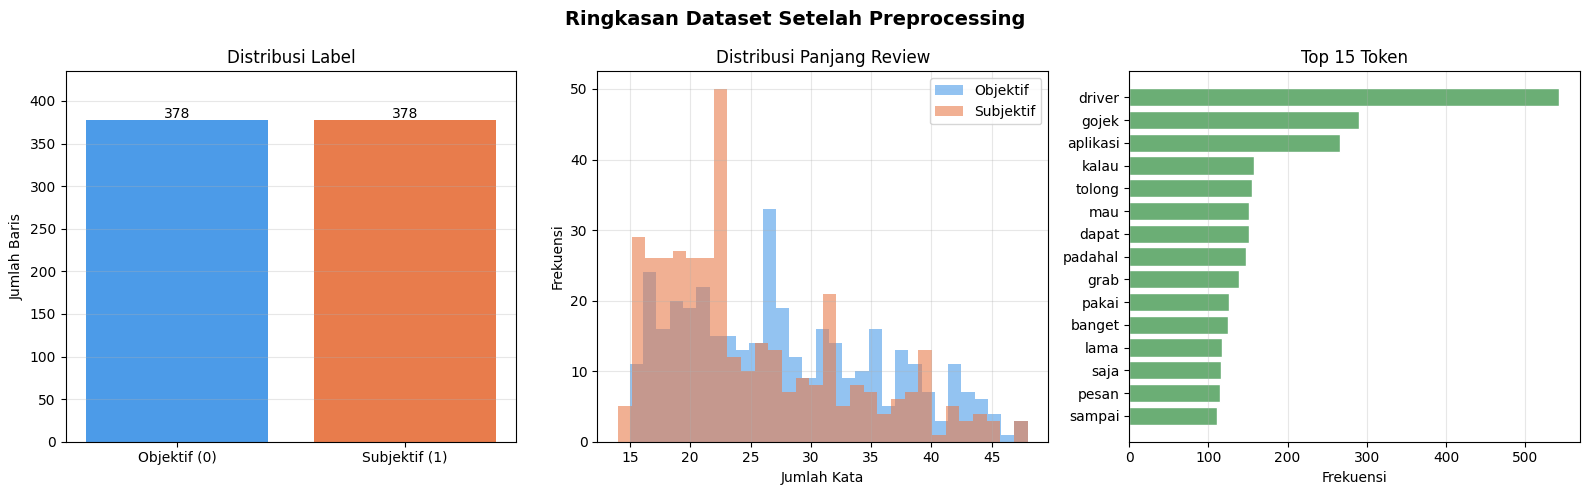

Plot disimpan -> preprocessing_summary.png


In [22]:
from collections import Counter
import matplotlib.pyplot as plt


def plot_ringkasan_preprocessing(df):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle('Ringkasan Dataset Setelah Preprocessing', fontsize=14, fontweight='bold')

    jumlah_label = df['label'].value_counts().reindex([0, 1], fill_value=0)
    nama_label = ['Objektif (0)', 'Subjektif (1)']
    warna_label = ['#4C9BE8', '#E87C4C']

    grafik_label = axes[0].bar(nama_label, jumlah_label.values, color=warna_label)
    for bar in grafik_label:
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            int(bar.get_height()),
            ha='center'
        )
    axes[0].set_title('Distribusi Label')
    axes[0].set_ylabel('Jumlah Baris')
    axes[0].set_ylim(0, jumlah_label.max() * 1.15)
    axes[0].grid(axis='y', alpha=0.3)

    panjang_objektif = df[df['label'] == 0]['review'].str.split().str.len()
    panjang_subjektif = df[df['label'] == 1]['review'].str.split().str.len()

    axes[1].hist(panjang_objektif, bins=30, alpha=0.6, color='#4C9BE8', label='Objektif')
    axes[1].hist(panjang_subjektif, bins=30, alpha=0.6, color='#E87C4C', label='Subjektif')
    axes[1].set_title('Distribusi Panjang Review')
    axes[1].set_xlabel('Jumlah Kata')
    axes[1].set_ylabel('Frekuensi')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    stopword_visual = {
        'yang', 'di', 'dan', 'saya', 'tidak', 'ini', 'ada', 'ke',
        'untuk', 'dengan', 'atau', 'pada', 'dari', 'tapi', 'juga',
        'bisa', 'sudah', 'nya', 'sama', 'itu', 'dalam', 'lagi'
    }

    hitung_kata = Counter()
    for review in df['review']:
        kata_penting = [
            kata for kata in review.split()
            if kata not in stopword_visual and len(kata) > 2
        ]
        hitung_kata.update(kata_penting)

    kata_teratas = hitung_kata.most_common(15)
    kata, frekuensi = zip(*kata_teratas)

    axes[2].barh(list(kata)[::-1], list(frekuensi)[::-1], color='#6BAE75', edgecolor='white')
    axes[2].set_title('Top 15 Token')
    axes[2].set_xlabel('Frekuensi')
    axes[2].grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.savefig('preprocessing_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Plot disimpan -> preprocessing_summary.png")


plot_ringkasan_preprocessing(df)


In [24]:
print("Ringkasan akhir:")
print(f"  Total data       : {len(df):,}")
print(f"  Jumlah kolom     : {df.shape[1]}")
print(f"  Duplikat review  : {df.duplicated(subset=['review']).sum()}")
print(f"  Review kosong    : {(df['review'].str.strip() == '').sum()}")
print(f"  Missing value    : {df.isna().sum().sum()}")
print(f"  Rata-rata kata   : {df['review'].str.split().str.len().mean():.1f}")
print(f"  Kata paling kecil: {df['review'].str.split().str.len().min()}")
print(f"  Kata paling besar: {df['review'].str.split().str.len().max()}")
print()



Ringkasan akhir:
  Total data       : 756
  Jumlah kolom     : 2
  Duplikat review  : 0
  Review kosong    : 0
  Missing value    : 0
  Rata-rata kata   : 26.3
  Kata paling kecil: 14
  Kata paling besar: 48

